Andrew Doherty Munro
DATA 30195
Final Project Notebook

$\textbf{Research Question and Motivation}$

I love being outside, and one thing I love about Chicago is its great parks - one of my favorite things to do in Hyde Park is to spend time at the Point and sit by the water. This project is meant to investigate park access in Chicago, as greenspace is great for exercise, mental health, heat reduction (through canopy coverage), etc. Therefore, I want to ask what demographic factors play into park access in the Chicago area? Do the expansion of parks displace people (mainly low income), either through pricing them out or displacing them with higher income people moving there?

$\textbf{Background and Literature Review}$

forthcoming

$\textbf{Data Sources}$

My main datasource is from the Trust for Public Land (TPL), which has a project called "10 Minute Walk Impact." The shapefiles used in this project can be access here: https://www.tpl.org/park-data-downloads

An unfortunate aspect of TPL's data is that they don't archive past files on their website, so I cannot use their data to see the changing area/coverage of parks. I am going to attempt to solve this by using the Multi-Resolution Land Characteristics Consortium Data, which includes its Land Cover Change: https://www.mrlc.gov/data

This will allow me to see year-over-year changes in land coverage in the Chicago area. I've never worked with Raster Data before, so I may have to pivot if I can't get reasonable traction with it.

Finally, I plan on using Census and ACS Data, specifically making use of MIGPUMAs. Chicago has 19 PUMAs, which should be enough for the purposes of this project to compare year-over-year. The ultimate goal is to see what sort of characteristics of movers precede and follow the expansion of park space.

$\textbf{Initial Results and Data Exploration}$

To begin, I want to explore the nature and characteristics of Chicago's Parks. For now, I am using Cook County as the definition of "Chicago," as the data from the Trust for Public Land includes counties and metropolitan areas,and I don't think clipping to just city limits would be informative. The metro area is quite large and ranges as far as Indiana, which I consider a stretch to call "Chicago."

In [21]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

Load in generic "Parks" shapefile, subset to Chicago and project to Illinois State Plane East CRS:

In [22]:
parks = gpd.read_file(r'data/shapefiles/Parks.shp')

chicago_parks = parks[(parks['Park_State'] == 'Illinois') & (parks['Park_Count'] == 'Cook County')]
chicago_parks = chicago_parks.to_crs(epsg=26971)

Plot to get a sense of coverage:

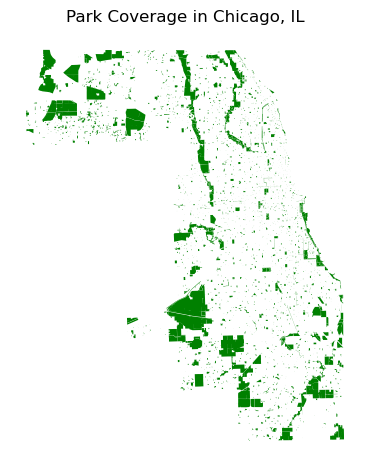

In [23]:
fig, ax = plt.subplots(1, 1)

chicago_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Park Coverage in Chicago, IL')

plt.tight_layout()
plt.show()

Land Trust also Includes a shapefile with helpful statistics attached to each park. However, it doesn't include counties! So a spatial join with the previous shapefile is necessary to get all the info at the county level:

In [24]:
park_stats = gpd.read_file(r'data/shapefiles/Parks_Statistics.shp')
park_stats = park_stats.to_crs(chicago_parks.crs)

#strip out duplicate columns for merging
cols_to_keep = []

for col in park_stats.columns.to_list():
    if col not in chicago_parks.columns.to_list():
        cols_to_keep.append(col)
    elif col == 'geometry':
        cols_to_keep.append(col)
    else:
        pass

park_stats = park_stats[cols_to_keep]

chicago_parks_full = chicago_parks.sjoin(park_stats,
                                how='left',
                                predicate='intersects')

chicago_parks_full.head()

,ParkID,GISTrkrID,SourceID,Park_Name,Park_Desig,Park_Owner,Park_Local,Park_Manag,Park_Loc_1,Park_Acces,...,SUM_TOTHHS,SUM_WHITE_,SUM_BLACK_,SUM_AMERIN,SUM_ASIAN_,SUM_PACIFI,SUM_OTHRAC,SUM_RACE2U,SUM_HISP_S,Park_Pla_1
34264,1701010-0001,3692,1,Laramie Park,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,477.0,842.0,119.0,3.0,41.0,1.0,2.0,28.0,339.0,1701010
34265,1701010-0002,3692,2,Kiwanis Park,LP,MUNI,VILLAGE OF ALSIP,MUNI,VILLAGE OF ALSIP,3,...,464.0,763.0,114.0,3.0,37.0,1.0,1.0,24.0,312.0,1701010
34266,1701010-0003,3692,3,Freedom Park,LP,SPECIAL_DISTRICT,METRO WATER RECLM DIST,SPECIAL_DISTRICT,METRO WATER RECLM DIST,3,...,486.0,560.0,224.0,1.0,30.0,0.0,1.0,26.0,313.0,1701010
34267,1701010-0004,3692,4,Ketelaar Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,189.0,162.0,130.0,0.0,12.0,0.0,3.0,13.0,204.0,1701010
34268,1701010-0005,3692,5,Lacrosse Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,191.0,227.0,44.0,1.0,11.0,0.0,0.0,7.0,99.0,1701010


How many parks are there in Cook County?

In [25]:
print('There are', len(chicago_parks_full), 'parks in Cook County')

There are 3176 parks in Cook County


There is an "Area" column, but it's not clear what the units are, which warrants investigation:

In [26]:
#Illinois State Plane East uses meters for area, so take that and convert to acres:
chicago_parks_full['area_sqm'] = chicago_parks_full.geometry.area
chicago_parks_full['area_acres'] = chicago_parks_full.geometry.area * 0.000247105

chicago_parks_full[['area_sqm', 'area_acres', 'Park_Size_']].head()

,area_sqm,area_acres,Park_Size_
34264,9738.849271,2.406518,2.406503
34265,6745.211133,1.666775,1.666764
34266,10157.568842,2.509986,2.509964
34267,2182.226756,0.539239,0.539231
34268,727.544414,0.179780,0.179778


It looks like "Park_Size_" measures acres! Now we can ask where/what the biggest parks are. There are a lot of parks (over 3,100!), so a reasonable sample is the top 5%, or about 150 parks.

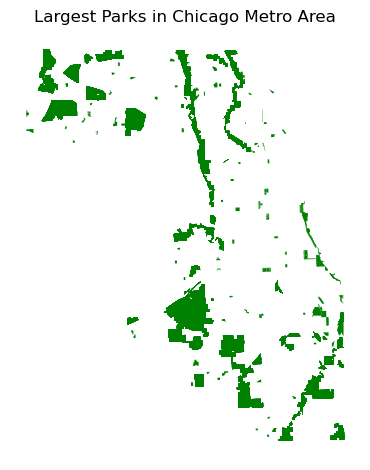

In [27]:
top_5p = np.quantile(chicago_parks_full['Park_Size_'], q=0.95)

biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, ax = plt.subplots(1, 1)

biggest_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Largest Parks in Chicago Metro Area')

plt.tight_layout()
plt.show()

Some of these are quite large, but others aren't as massive, and they're pretty spread out so there's good variation. Who has access to these parks? Can start by using the included income statistics, which TPL includes. All statistics are represented by people who live within a 10-minute walk to a given park, which serves as a proxy of access.

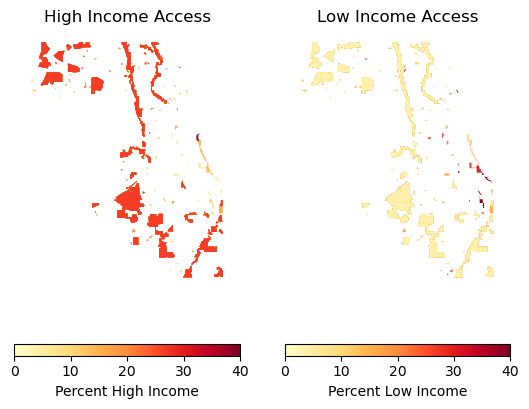

In [28]:
chicago_parks_full['pct_high_inc'] = 100* chicago_parks_full['SUM_HHIHIG'] / chicago_parks_full['SUM_TOTPOP']
chicago_parks_full['pct_low_inc'] = 100 * chicago_parks_full['SUM_HHILOW'] / chicago_parks_full['SUM_TOTPOP']

#refilter to biggest parks so that it includes new columns
biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, (ax1, ax2) = plt.subplots(1, 2)

biggest_parks.plot(
    column='pct_high_inc',
    ax=ax1,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent High Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

biggest_parks.plot(
    column='pct_low_inc',
    ax=ax2,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent Low Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

ax1.set_title('High Income Access')
ax2.set_title('Low Income Access')
ax1.set_axis_off()
ax2.set_axis_off()

plt.show()

There's a huge discrepancy! Taking the largest parks, it seems like high income people (as measured by being >125% of median income) are much more likely to be near parks.

Another interesting thing that TPL tracks is in a separate .csv, called "canopy pct". This measures what percentage of the area of a park is canopy, or covered by trees.

In [29]:
add_stats = pd.read_csv('data/shapefiles/AdditionalData.csv')

chicago_parks_full = chicago_parks_full.merge(add_stats, on='ParkID', how='left')

There's a pretty significant outlier:

In [36]:
chicago_parks_full['canopy_pct'].max()

np.float64(249.27074255109775)

Which is likely just measurement error, so we can omit. Once we take that out, is there a relationship between canopy coverage (presumably more desirable) and income?

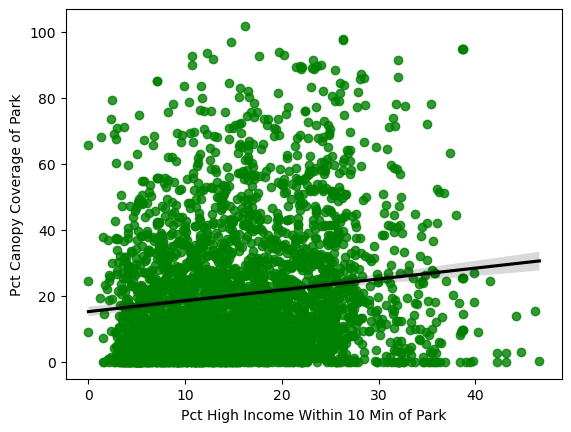

In [41]:
chicago_parks_full = chicago_parks_full[chicago_parks_full['canopy_pct'] < 249]

import seaborn as sns

fig, ax = plt.subplots(1, 1)

sns.regplot(data = chicago_parks_full,
            x='pct_high_inc',
            y='canopy_pct',
            color='green',
            line_kws={'color': 'black'}
            )

ax.set_xlabel('Pct High Income Within 10 Min of Park')
ax.set_ylabel('Pct Canopy Coverage of Park')

plt.show()

It seems like there's something there! but the data is very messy given how many parks we have.